In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Read churn_cleaned.csv from the Customer_churn_analysis folder
file_path = '/content/drive/MyDrive/Customer_churn_analysis/churn_cleaned.csv'
df = pd.read_csv(file_path)

print("✓ File loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Mounted at /content/drive
✓ File loaded successfully!
Shape: (7043, 10)

First 5 rows:
   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      41             1              0   
2       0              0           1      52             1              0   
3       0              0           0       1             1              0   
4       1              0           0      67             1              0   

   InternetService  Contract  MonthlyCharges  Churn  
0                0         0              25      1  
1                0         1              25      0  
2                0         0              19      0  
3                0         1              76      1  
4                1         0              51      0  

Column names:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contra

In [5]:
X = df.drop("Churn", axis=1)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

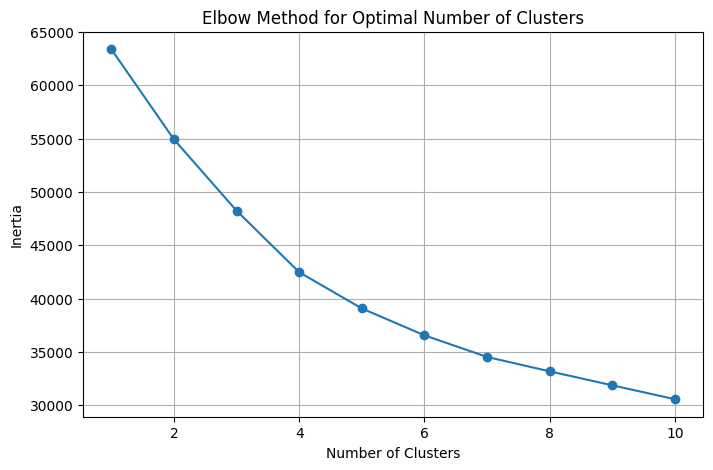

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig("elbow_plot.png")
plt.show()

In [9]:
optimal_k = 3

In [10]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [11]:
df["Cluster"] = clusters

In [12]:
print("\nClustered dataset preview:")
print(df.head())


Clustered dataset preview:
   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      41             1              0   
2       0              0           1      52             1              0   
3       0              0           0       1             1              0   
4       1              0           0      67             1              0   

   InternetService  Contract  MonthlyCharges  Churn  Cluster  
0                0         0              25      1        1  
1                0         1              25      0        2  
2                0         0              19      0        2  
3                0         1              76      1        2  
4                1         0              51      0        0  


In [16]:

clustered_df = pd.read_csv('clustered_data.csv')
clustered_df.to_csv('/content/drive/MyDrive/Customer_churn_analysis/clustered_data.csv', index=False)

print("✓ File saved to Google Drive:")
print("/content/drive/MyDrive/Customer_churn_analysis/clustered_data.csv")

✓ File saved to Google Drive:
/content/drive/MyDrive/Customer_churn_analysis/clustered_data.csv


In [15]:
print("\nCluster distribution:")
print(df["Cluster"].value_counts())


Cluster distribution:
Cluster
2    3566
0    2795
1     682
Name: count, dtype: int64


In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

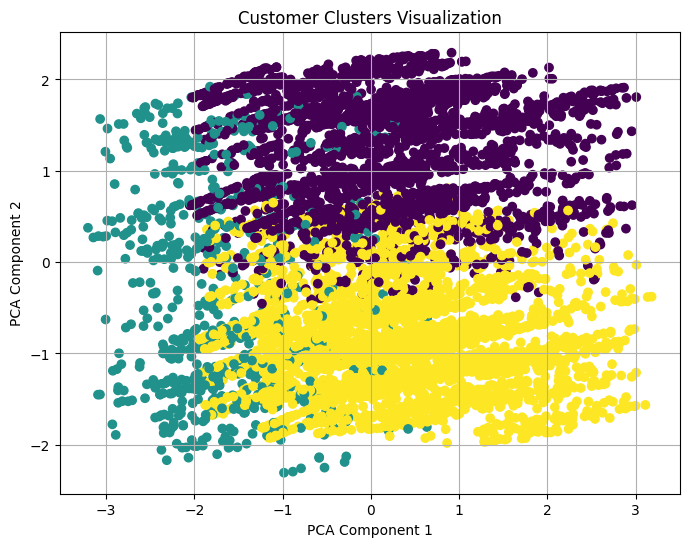

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Customer Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.savefig("cluster_visualization.png")
plt.show()

In [19]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
           gender  SeniorCitizen  Dependents     tenure  PhoneService  \
Cluster                                                                 
0        0.523792       0.157424    0.315564  33.034347           1.0   
1        0.514663       0.152493    0.302053  31.737537           0.0   
2        0.487942       0.167695    0.286596  31.972518           1.0   

         MultipleLines  InternetService  Contract  MonthlyCharges     Churn  
Cluster                                                                      
0             0.632916         1.000000  0.447943       66.981753  0.256887  
1             0.381232         0.441349  0.711144       42.017595  0.249267  
2             0.264162         0.000000  0.876612       67.365676  0.275098  


In [20]:
cluster_summary.to_csv("cluster_summary.csv")
print("Cluster summary saved as cluster_summary.csv")

Cluster summary saved as cluster_summary.csv


In [24]:
from google.colab import files

files.download("elbow_plot.png")
files.download("cluster_visualization.png")
files.download("clustered_data.csv")
files.download("cluster_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>